# Dataset Detección De Objetos

En este cuaderno se detalla el dataset empleado para entrenar el modelo de detección de objetos. El objetivo es poder entrenar un modelo capaz de, dada una imagen, marcar el balón, los jugadores y los árbitros.

El marcado se realizará mediante Bounding Boxes (BB)

## Dataset SoccerNet

SoccerNet ofrece un dataset con imagenes marcadas. 

Realmente se tratan de clips de 30 segundos; cada uno de ellos a 25 FPS. En consecuencia, cada clip proporciona $ 30 \cdot 25 = 750 $ imagenes.

Todas las imagenes tiene una resolución de $1920$ x $ 1080$ pixeles en formato JPG

El dataset está dividido en Train y Test:

Train:

-  57 clips que equivalen a  $57 \cdot (30 \cdot 25) = 42.750$ imagenes

Test:

- 49 clips que equivalen a  $49 \cdot (30 \cdot 25) = 36.750$ imagenes

    
#### Formato Original

Cada clip está compuesto por 2 carpetas y 2 archivos.

Carpetas:
- img1: Contiene las $750$ imagenes enumeradas del 000001 al 000750
- det: Contiene un archivo llamado det.txt en formato csv con información relativa al marcado de los objetos de TODAS las imagenes. Cada linea tiene el siguiente formato:


    - \<Frame ID, Track ID, Coordenada X Esquina Superior Izquierda del BB, Coordenada Y Esquina Superior Izquierda del BB\, Acho del BB, Alto del BB, 1, -1, -1, -1>

        - Frame ID: número de imagen
        - Track ID: número que representa el tipo de objeto

    
Archivos:

- gameinfo.ini: Contiene información relativa al partido y, en particular, la relación Track_ID \<--\> Objeto
- seqinfo.ini: Contiene información relativa al clip
    - Frame rate
    - Número de imagenes totales que conforman el clip
    - Extensión de las imagenes
    - Resolución de las imagenes



In [1]:
from ia_futbol.utils.config import OBJ_DETECTION_DATA
import os

In [2]:
#Ruta al dataset original
TRAIN_PATH = os.path.join(OBJ_DETECTION_DATA,"train")
TEST_PATH= os.path.join(OBJ_DETECTION_DATA,"test")

In [ ]:
from SoccerNet.Downloader import SoccerNetDownloader
mySoccerNetDownloader = SoccerNetDownloader(LocalDirectory=OBJ_DETECTION_DATA)
mySoccerNetDownloader.downloadDataTask(task="tracking-2023", split=["train", "test"])

Mostramos una imagen  y su correspondiente marcado:

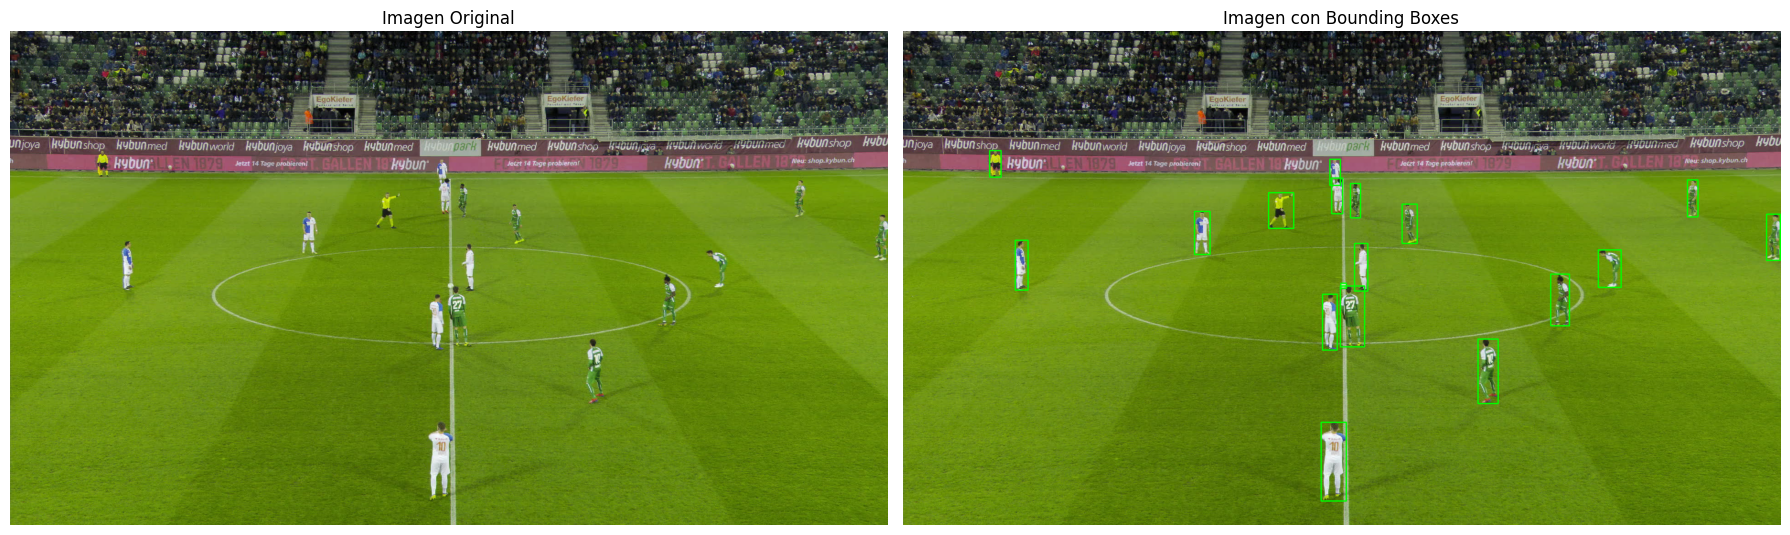

In [48]:
import matplotlib.pyplot as plt
import cv2
import pandas as pd

#Rutas
clip_path = f'{TRAIN_PATH}/SNMOT-060' #Ruta a un clip
img_path = f'{clip_path}/img1/000001.jpg' #Imagen 1 del clip SNMOT-060
det_info_path = f'{clip_path}/det/det.txt' #Ruta al .txt con las marcaciones

#Obtenemos relacion TRACK_ID <-> Tipo Objeto

img = cv2.imread(img_path)
img_bb = img.copy()

#Marcamos los Bounding Boxes
det_info = pd.read_csv(det_info_path,header=None)

for idx, row in det_info.iterrows():
    frame_id = int(row.iloc[0])
    if frame_id != 1:
        break

    x, y, w, h = int(row.iloc[2]), int(row.iloc[3]), int(row.iloc[4]), int(row.iloc[5]) #iloc selecciona el elemento en la pos n
    color = (0, 255, 0)  # verde
    cv2.rectangle(img_bb, (x, y), (x + w, y + h), color, 2)
        
    
img1 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img_bb, cv2.COLOR_BGR2RGB)

# Crear figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Mostrar primera imagen
axes[0].imshow(img1)
axes[0].set_title("Imagen Original")
axes[0].axis("off")

# Mostrar segunda imagen
axes[1].imshow(img2)
axes[1].set_title("Imagen con Bounding Boxes")
axes[1].axis("off")

plt.tight_layout()
plt.show()



# Modificación Dataset
Cambiaremos la estructura del dataset y como se almacenan las etiquetas para facilitar el trabajo con los datos.

Por cada clip tendremos una carpeta img1 donde se almacenarán las imagenes y otra llamada labels donde se almacenaran tantos archivos txt como imagenes contenga cada clip.
Cada uno de estos archivos .txt tendrá el mismo nombre que su imagen asociada y contendrá las anotaciones de dicha imagen.
Cada linea representará un objeto de la imagen y tendrá el siguiente formato:


- \<Typye Object, Coordenada X Esquina Superior Izquierda del BB, Coordenada Y Esquina Superior Izquierda del BB\, Acho del BB, Alto del BB>

       

Para ello definimos un par de funciones que permitan extraer la información original almacenada en gt y gameinfo.ini.




In [49]:
import os
import configparser
import pandas as pd

def read_gameinfo(gameinfo_path):
    """
    Lee el archivo en gameinfo_path que contiene la relación track_id <-> tipo de objeto
    y devuelve un diccionario del mismo estilo pero en formato númerico
    (Abrir archivo gameinfo.ini para entenderlo mejor)
    Args:
        gameinfo_path: ruta al archivo gameinfo_path.ini
        

    Returns:
        trakc_id: diccionario (trakc_id, tipo_objeto)
    """

    object_dict = {
    "ball": 0,
    "player": 1,
    "referee": 2
    }

    config = configparser.ConfigParser()
    config.read(gameinfo_path)
    track_id = {}  #Diccionario TRACK_ID <---> Objeto 

    for key in config["Sequence"]:
            
        if key.lower().startswith("trackletid_"):
            id =  int(key.split("_")[1])  #número id

            #Filtramos el tipo de objeto
            object_type = config["Sequence"][key]
            object_type = object_type.split(";")[0].strip().lower() #Sepaaramos hasta el ; (ver gameinfo.ini)
            object_type = object_type.split()[0]

            if object_type not in {"ball","player","referee"}:
                track_id[id] = 1
            else:
                track_id[id] = object_dict[object_type]

    return track_id
        

def read_gt(gt_path,track_id,convert_format):
    """
    Lee el archivo en gt_path con las marcaciones en el formato original y devuelve
    un diccionario con la misma información pero en un nuevo formato
    Args:
        gt_path: ruta al archivo gt.txt
        convert_format: función que recibe una linea y la devuelve en otro formato

    Returns:
        gt: diccionario (frame_id, [detections])
    """

    gt_info = pd.read_csv(gt_path,header=None)
    gt = {}

    for idx, row in gt_info.iterrows():
        frame_id = int(row.iloc[0])
        new_format = convert_format(row,track_id)
        gt.setdefault(frame_id, []).append(new_format)

    return gt



Además definiremos una nueva función que, a posteriori, nos permitirá crear también nuevos formatos de etiqueta para entrenar  modelos:

In [50]:
def soccernet_format_to(folder,convert_format,ouput_format):
    """
    Lee el dataset entero clip a clip. Por cada clip extrae la informacion relativa y la transforma en otro formato
    meidante la funcion convert_format. Finalmente, ouput_format se encarga de almacenar dichos datos transformados
    Args:
        folder: carpeta Train,Val, o Test
        convert_format: función que recibe una linea y la devuelve en otro formato
        output_format: funcion que recibe 
            clip_path
            gt (diccionario (frame_id, [detections])) y 
            track_id (diccionario (trakc_id, tipo_objeto))

    """

    clips = os.listdir(folder) #Lista de carpetas/clips

    for clip in clips:
        clip_path = f'{folder}/{clip}'
        gt_info_path= f'{clip_path}/gt/gt.txt'
        gameinfo_path = f'{clip_path}/gameinfo.ini'

        track_id = read_gameinfo(gameinfo_path)
        labels_new_format = read_gt(gt_info_path,track_id,convert_format)
        

        ouput_format(clip_path,labels_new_format)

Procedemos crear el nuevo formato:

In [51]:
def txt_format(soccernet_row,track_id):
    frame_id = int(soccernet_row.iloc[0])
    id = int(soccernet_row.iloc[1])
        

    x, y, w, h = int(soccernet_row.iloc[2]), int(soccernet_row.iloc[3]), int(soccernet_row.iloc[4]), int(soccernet_row.iloc[5]) #iloc selecciona el elemento en la pos n
  
    new_line = f"{track_id[id]} {x} {y} {w} {h}"
    return new_line


def txt_output_format(clip_path,labels_new_format):
    new_labels = f'{clip_path}/labels'
    os.makedirs(new_labels,exist_ok=True)

    for frame_id, lines in labels_new_format.items():
        filename = f"{frame_id:06d}.txt"  # 
        path_out = os.path.join(new_labels, filename)
        with open(path_out, "w") as f:
            f.write("\n".join(lines))


In [52]:
#soccernet_format_to(folder=TEST_PATH,convert_format=txt_format,ouput_format=txt_output_format)
soccernet_format_to(folder=TRAIN_PATH,convert_format=txt_format,ouput_format=txt_output_format)

Con este nuevo formato podremos trabajar de manera mas amena

# Reducción del Dataset

Veamos un problema que tiene este dataset. Como hemos comentado el dataset está compuesto por clips de 30 segundos a 25 FPS, es decir, 25 imagenes representan un solo segundo del clip.En consecuencia, si fijamos un clip cualquiera y observamos las primeras 25 imagenes observaremos que son practicamente iguales y esto se aplica, sucesivamente, a  los siguientes intervalos de 25 imagenes.

In [ ]:
import matplotlib.pyplot as plt
import cv2


clip_path = f'{TRAIN_PATH}/SNMOT-060' #Ruta a un clip

plt.figure(figsize=(105, 105))
for i in range(1,11):
    img_path = f'{clip_path}/img1/{i:06d}.jpg' #Imagen 1 del clip SNMOT-060
    img = cv2.imread(img_path)

    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.subplot(5, 5, i)
    plt.imshow(img)
    plt.title(f"{i:06d}.jpg",fontsize = 70)
    plt.axis("off")


plt.tight_layout()
plt.show()

Se observa que son practicamente iguales las imagenes, y esto puedo causar overfiting, por lo que hemos decidido filtrar el dataset.
Para ello crearemos una carpeta llamada "dataset" que contendrá tres carpetas: Train, Val y Test.

Cada una de estas carpetas contendrá, a su vez, al menos dos carpetas: imgs y labels.

- imgs: imagenes en formato .jpg
- labels: etiquetas en formato .txt. Tantos archivos .txt como imagenes. Cada .txt tendrá el mismo nombre que su imagen asociada y cada linea representará
un objeto de la imagen con el siguiente formato:
    - \<Typye Object, Coordenada X Esquina Superior Izquierda del BB, Coordenada Y Esquina Superior Izquierda del BB\, Acho del BB, Alto del BB>

Nuestro objetivo es dividir los 106 clips en proporciones de 80% train, 10% val y 10% test, es decir:

- Train: 86 clips
- Val: 10 clips
- Test: 10 clips

En consecuencia, y teniendo en cuenta que tomaremos una 1 imagen de media por segundo ($\iff$ 30 imagenes por clip) el nuevo dataset contendrá:

- Train:  $2580$ imagenes
- Val:  $300$ imagenes
- Test:  $300$ imagenes


Un total de  $3180$ imagenes



In [63]:
import shutil

new_train_path = os.path.join(OBJ_DETECTION_DATA,"train")
new_test_path = os.path.join(OBJ_DETECTION_DATA,"test")
new_val_path = os.path.join(OBJ_DETECTION_DATA,"val")

#Carpetas
os.makedirs(new_train_path,exist_ok=True)
os.makedirs(new_test_path,exist_ok=True)
os.makedirs(new_val_path,exist_ok=True)

#Carpetas Imagenes y Etiquetas
os.makedirs(os.path.join(new_train_path,"images"),exist_ok=True)
os.makedirs(os.path.join(new_train_path,"labels"),exist_ok=True)
os.makedirs(os.path.join(new_train_path,"soccernet_labels"),exist_ok=True)

os.makedirs(os.path.join(new_test_path,"images"),exist_ok=True)
os.makedirs(os.path.join(new_test_path,"labels"),exist_ok=True)
os.makedirs(os.path.join(new_test_path,"soccernet_labels"),exist_ok=True)

os.makedirs(os.path.join(new_val_path,"images"),exist_ok=True)
os.makedirs(os.path.join(new_val_path,"labels"),exist_ok=True)
os.makedirs(os.path.join(new_val_path,"soccernet_labels"),exist_ok=True)

In [64]:
import os
import shutil

def move_to(clip_path, new_path, img_number):
    """
    Mueve el contenido de un clip con ruta clip_path a la nueva ruta new_path
    """

    imgs_path = os.path.join(clip_path, "img1")
    imgs = sorted(os.listdir(imgs_path))

    for i in range(1, 31):
        # Nombre del archivo actual
        img_filename = imgs[25*(i-1)]
        
        # Rutas originales
        img_path = os.path.join(imgs_path, img_filename)
        label_path = os.path.join(clip_path, "labels", f"{img_filename.split('.')[0]}.txt")

        # Rutas destino
        new_img_path = os.path.join(new_path, "images", f"{img_number:06d}.jpg")
        new_label_path = os.path.join(new_path, "soccernet_labels", f"{img_number:06d}.txt")

        # Mover los archivos (sustituye a os.symlink)
        shutil.copy(img_path, new_img_path)
        shutil.copy(label_path, new_label_path)

        img_number += 1

    return img_number


In [65]:
# Recorremos la carpeta Train 
train_clip_number = 1 # numero de clips movidas a Train
train_img_number = 1
clips_path = os.listdir(TRAIN_PATH)

for clip in clips_path:
    if clip != "images" and clip != "labels" and clip != "soccernet_labels":
        train_img_number = move_to(clip_path=os.path.join(TRAIN_PATH, clip), new_path=new_train_path, img_number=train_img_number)
        train_clip_number += 1
    

# Recorremos la carpeta Test
val_clip_number = 1
val_img_number = 1

test_clip_number = 1
test_img_number = 1

clips_path = os.listdir(TEST_PATH)

for clip in clips_path:
    if clip != "images" and clip != "labels" and clip != "soccernet_labels":
        if train_clip_number <= 86:
            train_img_number = move_to(clip_path=os.path.join(TEST_PATH, clip), new_path=new_train_path, img_number=train_img_number)
            train_clip_number += 1
        elif val_clip_number <= 10:
            val_img_number = move_to(clip_path=os.path.join(TEST_PATH, clip), new_path=new_val_path, img_number=val_img_number)
            val_clip_number += 1
        else:
            test_img_number = move_to(clip_path=os.path.join(TEST_PATH, clip), new_path=new_test_path, img_number=test_img_number)
            test_clip_number += 1

# Formato YOLO

Uno de los modelos que usaremos para la detección de objetos será YOLO (You Only Look Once) y para ello necesitamos cambiar el formato de las etiquetas.

YOLO requiere tener para cada conjunto de imagenes (Train, test y val) tener 2 carpetas:

- images: carpeta que contiene las imagenes
- labels: carpeta que contiene los archivos de anotaciones correspondientes a cada imagen

    - Hay tantos archivos como imagenes y con el mismo nombre que la imagen
    - Cada archivo es un .txt con el siguiente formato:
        - <class_id> <x_center> <y_center> \<ancho\> \<altura\>
            - class_id : un entero que representa la clase de objeto
                - 0 : Balón
                - 1 : Jugador
                - 2 : Árbitro
            - x_center, y_center, ancho y altura: coordenadas NORMALIZADAS del BB  


Definimos las funciones correspondientes al formato YOLO:

In [66]:
WIDTH = 1920
HEIGTH = 1080


def yolo_format(soccernet_row):
    parts = soccernet_row.strip().split()
    
    class_id = parts[0]
    x = float(parts[1])
    y = float(parts[2])
    w = float(parts[3])
    h = float(parts[4])
    
    # Normalización
    x_center = (x + w/2) / WIDTH
    y_center = (y + h/2) / HEIGTH
    w_norm = w / WIDTH
    h_norm = h / HEIGTH
    
    return f"{class_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}"


def yolo_format_output(set_path):

    labels_path = f"{set_path}/soccernet_labels"
    os.makedirs(f"{set_path}/labels",exist_ok=True)

    labels = os.listdir(labels_path)

    for label in labels:

        with open(f"{labels_path}/{label}") as l:
            bounding_boxes = l.readlines()
            yolo_bounding_boxes = [yolo_format(bb) for bb in bounding_boxes]
            with open(f"{set_path}/labels/{label}","w") as f:
                for bb in yolo_bounding_boxes:
                    f.write(bb + "\n")



In [69]:
TRAIN_PATH = os.path.join(OBJ_DETECTION_DATA,"train")
TEST_PATH = os.path.join(OBJ_DETECTION_DATA,"test")
VAL_PATH = os.path.join(OBJ_DETECTION_DATA,"val")

In [70]:
yolo_format_output(TRAIN_PATH)
yolo_format_output(TEST_PATH)
yolo_format_output(VAL_PATH)

Comprobemos que la conversión es correcta:

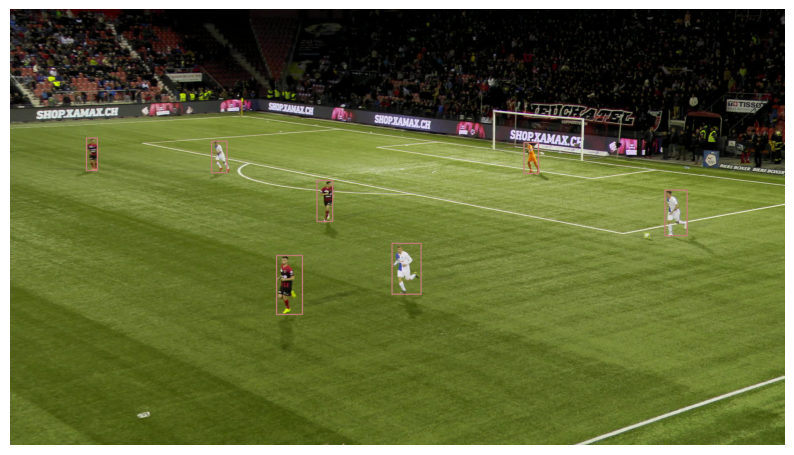

In [72]:
import sys
import utils.image_tools as it


#Rutas
img_path =os.path.join(TRAIN_PATH, "images","000700.jpg")
yolo_label_path = os.path.join(TRAIN_PATH, "labels","000700.txt")

it.display_image(it.annotate_yolo(img_path,yolo_label_path))


# Análisis del Dataset

### Clases
Estudiaremos cuantas instancias hay de cada clase (jugador, balón o arbitro).



In [3]:
import os
import matplotlib.pyplot as plt

TRAIN_PATH = os.path.join(OBJ_DETECTION_DATA,"train")
TEST_PATH = os.path.join(OBJ_DETECTION_DATA,"test")
VAL_PATH = os.path.join(OBJ_DETECTION_DATA,"val")

TRAIN_SIZE = len(os.listdir(os.path.join(TRAIN_PATH,"images")))


In [4]:
num_players = 0 
num_balls = 0
num_referees = 0

labels_path = os.path.join(TRAIN_PATH,"labels")
labels = os.listdir(labels_path)

for label in labels:

    with open(f"{labels_path}/{label}") as f:
        for line in f:
            type = line.split()[0]

            if int(type) == 0:
                num_balls +=1
            elif int(type) == 1:
                num_players +=1
            else:
                num_referees +=1


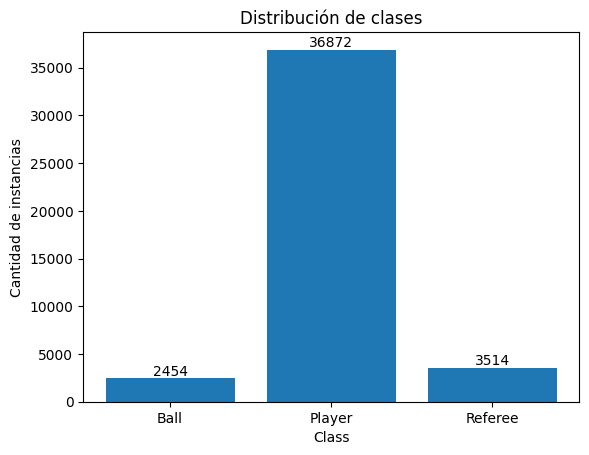

In [5]:
classes = ["Ball","Player","Referee"]
values = [num_balls,num_players,num_referees]

bar = plt.bar(classes, values)
plt.bar_label(bar)
plt.xlabel("Class")
plt.ylabel("Cantidad de instancias")
plt.title("Distribución de clases")
plt.show()


### Número de Objetos por Imagen

Calcularemos el número medio de cada objeto  que aparece por imagen



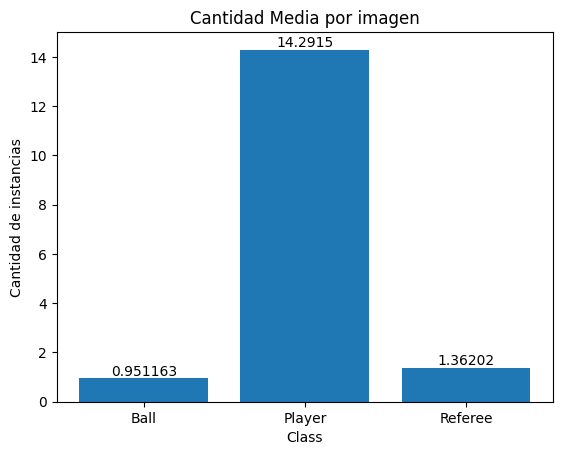

In [6]:
labels = os.listdir(os.path.join(TRAIN_PATH,"labels"))
mean = {"0": 0, "1": 0, "2":0}

for label in labels:
    
    #<Typye Object, Coordenada X Esquina Superior Izquierda del BB, Coordenada Y Esquina Superior Izquierda del BB, Acho del BB, Alto del BB>
    with open(file=os.path.join(TRAIN_PATH,"labels",label)) as f:
        lines = f.readlines()
        for line in lines:
            mean[line[0]] +=1


mean["0"] = mean["0"]/TRAIN_SIZE
mean["1"] = mean["1"]/TRAIN_SIZE
mean["2"] = mean["2"]/TRAIN_SIZE


classes = ["Ball","Player","Referee"]

bar = plt.bar(classes, mean.values())
plt.bar_label(bar)
plt.xlabel("Class")
plt.ylabel("Cantidad de instancias")
plt.title("Cantidad Media por imagen")
plt.show()

    


### Imagenes con balón

Vamos a calcular cuantas imagenes tienen un balón en la imagen

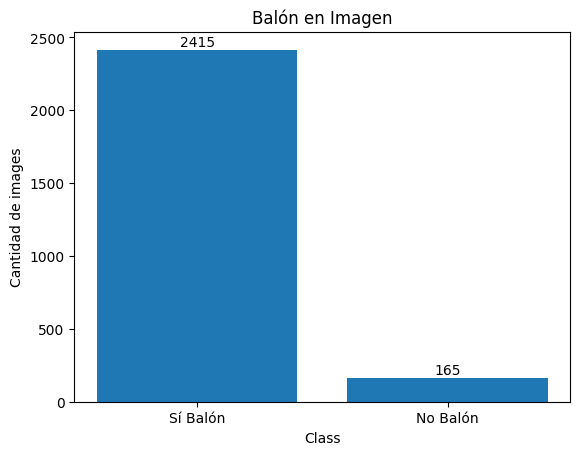

In [7]:
labels = os.listdir(os.path.join(TRAIN_PATH,"labels"))
count = 0

for label in labels:
    
    #<Typye Object, Coordenada X Esquina Superior Izquierda del BB, Coordenada Y Esquina Superior Izquierda del BB, Acho del BB, Alto del BB>
    with open(file=os.path.join(TRAIN_PATH,"labels",label)) as f:
        for line in f:
            if line[0] == "0":
                count +=1
                break

bar = plt.bar(x=["Sí Balón","No Balón"],height=[count,TRAIN_SIZE-count])
plt.bar_label(bar)
plt.xlabel("Class")
plt.ylabel("Cantidad de images")
plt.title("Balón en Imagen")
plt.show()

### Area media por instancia
Vamos a calcular el area media del bounding box que ocupa una instancia de cada clase y su correspondiente porcentaje respecto la imagen total.



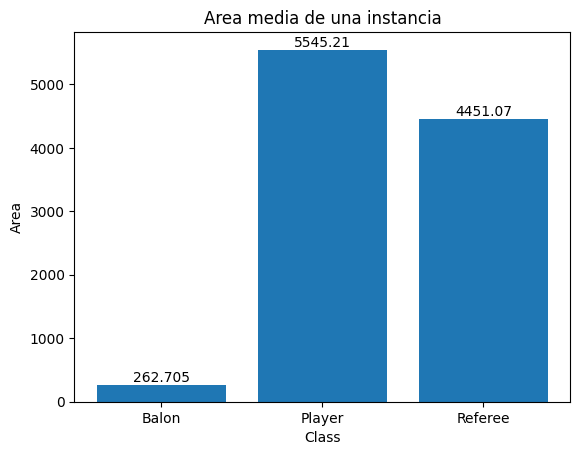

In [8]:
labels = os.listdir(os.path.join(TRAIN_PATH,"soccernet_labels"))
mean_width = {"0":0,"1":0,"2":0}
mean_height = {"0":0,"1":0,"2":0}
mean_area = {"0":0,"1":0,"2":0}
count = {"0":0,"1":0,"2":0}

for label in labels:
    
    #<Typye Object, Coordenada X Esquina Superior Izquierda del BB, Coordenada Y Esquina Superior Izquierda del BB, Acho del BB, Alto del BB>
    with open(file=os.path.join(TRAIN_PATH,"soccernet_labels",label)) as f:
        for line in f:
            class_id, _,_,width,height = line.strip().split()

            count[class_id] += 1
            mean_width[class_id] += float(width)
            mean_height[class_id] += float(height)
            mean_area[class_id] += float(width)*float(height)

mean_area["0"] = mean_area["0"]/count["0"]
mean_area["1"] = mean_area["1"]/count["1"]
mean_area["2"] = mean_area["2"]/count["2"]

mean_width["0"] = mean_width["0"]/count["0"]
mean_width["1"] = mean_width["1"]/count["1"]
mean_width["2"] = mean_width["2"]/count["2"]

mean_height["0"] = mean_height["0"]/count["0"]
mean_height["1"] = mean_height["1"]/count["1"]
mean_height["2"] = mean_height["2"]/count["2"]



bar = plt.bar(x=["Balon","Player","Referee"],height=mean_area.values())
plt.bar_label(bar)
plt.xlabel("Class")
plt.ylabel("Area")
plt.title("Area media de una instancia")
plt.show()

         

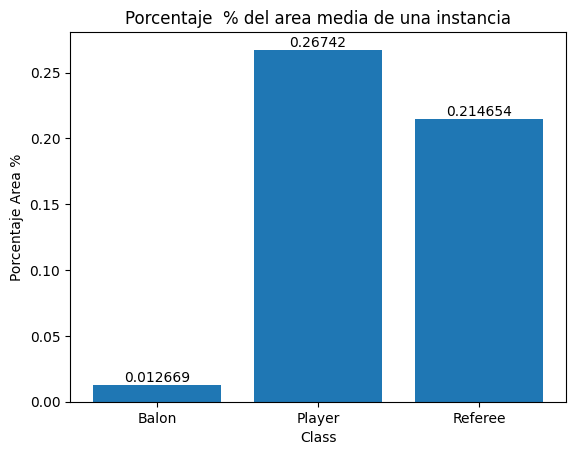

In [9]:
TOTAL_AREA =1920*1080

bar = plt.bar(x=["Balon","Player","Referee"],height=[mean_area[f"{i}"]/TOTAL_AREA * 100 for i in range(0,3)])
plt.bar_label(bar)
plt.xlabel("Class")
plt.ylabel("Porcentaje Area %")
plt.title("Porcentaje  % del area media de una instancia")
plt.show()


### Area media por clase
Calculamos el area media que ocupa toda una clase en una imagen

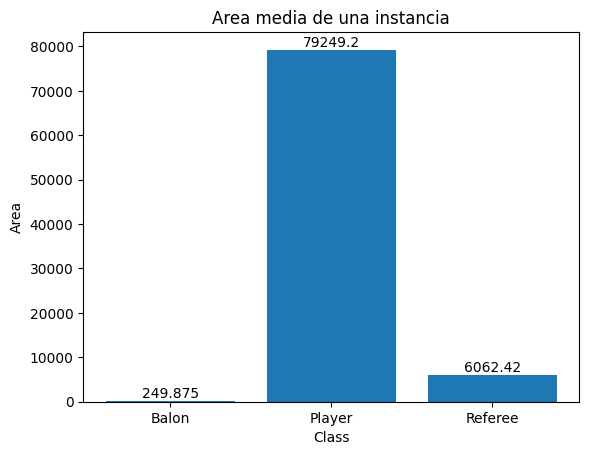

In [10]:
labels = os.listdir(os.path.join(TRAIN_PATH,"soccernet_labels"))
mean_area = {"0":0,"1":0,"2":0}

for label in labels:
    
    #<Typye Object, Coordenada X Esquina Superior Izquierda del BB, Coordenada Y Esquina Superior Izquierda del BB, Acho del BB, Alto del BB>
    with open(file=os.path.join(TRAIN_PATH,"soccernet_labels",label)) as f:
        for line in f:
            class_id, _,_,width,height = line.strip().split()
            mean_area[class_id] += float(width)*float(height)

mean_area["0"] = mean_area["0"]/TRAIN_SIZE
mean_area["1"] = mean_area["1"]/TRAIN_SIZE
mean_area["2"] = mean_area["2"]/TRAIN_SIZE

bar = plt.bar(x=["Balon","Player","Referee"],height= mean_area.values())
plt.bar_label(bar)
plt.xlabel("Class")
plt.ylabel("Area")
plt.title("Area media de una instancia")
plt.show()

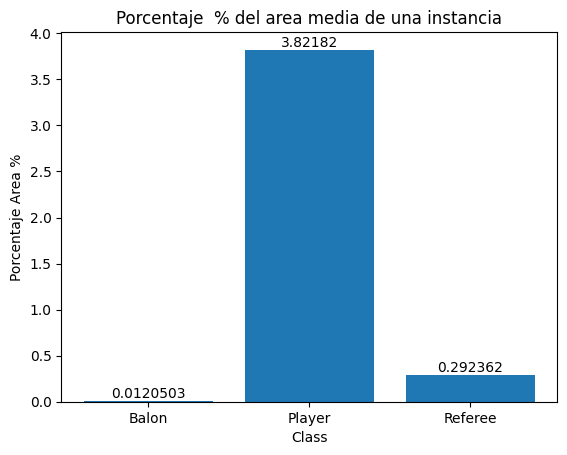

In [11]:
TOTAL_AREA =1920*1080

bar = plt.bar(x=["Balon","Player","Referee"],height=[mean_area[f"{i}"]/TOTAL_AREA * 100 for i in range(0,3)])
plt.bar_label(bar)
plt.xlabel("Class")
plt.ylabel("Porcentaje Area %")
plt.title("Porcentaje  % del area media de una instancia")
plt.show()

Se observa claramanete que los objetos en sí mismos ocupan muy poco espacio en una imagen dada